In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
x = np.array([1.0,2.0,3.0])
y = np.array([300.0,500.0,700.0])
w = 0.0
b = 0.0
alpha = 0.01
epocas = 10000

In [30]:
def calcular_previsao(x,w,b):
    """
    Calcula a previsão do modelo de regressão linear para um conjunto de dados.

    Parâmetros:
    x (ndarray): Vetor contendo os dados de entrada (ex: tamanho das casas).
    w (float): Peso (weight) atual do modelo.
    b (float): Viés (bias) atual do modelo.

    Retorna:
    previsao (ndarray): Vetor com as previsões matemáticas calculadas (w * x + b).
    """
    previsao = np.zeros(len(x))
    for i in range(len(x)):
        previsao[i] = w*x[i]+b
    return previsao

In [31]:
def calcular_custo(x,y,w,b):
    """
    Calcula a Função de Custo (Erro Quadrático Médio) para verificar a precisão do modelo.

    Parâmetros:
    x (ndarray): Vetor contendo os dados de entrada.
    y (ndarray): Vetor com os valores reais/alvo (ex: preço real das casas).
    w (float): Peso (weight) atual do modelo.
    b (float): Viés (bias) atual do modelo.

    Retorna:
    J (float): O valor numérico do custo total (quão longe a previsão está da realidade).
    """
    m = len(x)
    J = 0
    previsao_atual = 0
    for i in range(m):
        previsao_atual = w * x[i] + b
        J += (previsao_atual - y[i]) ** 2
    J /= (2 * m)
    return J

In [32]:
def calcular_gradiente(x,y,w,b):
    """
    Calcula o gradiente (derivadas parciais) da função de custo em relação aos parâmetros.

    Parâmetros:
    x (ndarray): Vetor contendo os dados de entrada.
    y (ndarray): Vetor com os valores reais.
    w (float): Peso (weight) atual do modelo.
    b (float): Viés (bias) atual do modelo.

    Retorna:
    dj_dw (float): Derivada do custo em relação ao peso (w). Indica a direção para minimizar o erro.
    dj_db (float): Derivada do custo em relação ao viés (b). Indica a direção para minimizar o erro.
    """
    m = len(x)
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        erro = (w * x[i] + b) - y[i]
        dj_db += erro
        dj_dw += erro * x[i]
    dj_db /= m
    dj_dw /= m 
    return dj_dw, dj_db

        

In [33]:
def gradiente_decendente(x,y,w,b,alpha,epocas):
    """
    Executa o algoritmo de Gradiente Descendente para otimizar (treinar) os parâmetros w e b.

    Parâmetros:
    x (ndarray): Vetor contendo os dados de entrada.
    y (ndarray): Vetor com os valores reais.
    w (float): Peso (weight) inicial.
    b (float): Viés (bias) inicial.
    alpha (float): Taxa de aprendizado (tamanho do passo de cada atualização).
    num_iteracoes (int): Quantidade de épocas (repetições) que o modelo vai treinar.

    Retorna:
    w (float): O peso final treinado e otimizado.
    b (float): O viés final treinado e otimizado.
    """
    for i in range(epocas):
        dj_dw,dj_db = calcular_gradiente(x,y,w,b)
        w = w - alpha*dj_dw
        b = b - alpha*dj_db
        if i % 100 == 0:
            print(f"Passo {i}: O Custo (Erro) está em {calcular_custo(x, y, w, b)}")
    return w, b
        
    

Passo 0: O Custo (Erro) está em 123414.42592592591
Passo 100: O Custo (Erro) está em 7.0702312029380145
Passo 200: O Custo (Erro) está em 4.48587598703673
Passo 300: O Custo (Erro) está em 3.526806211040094
Passo 400: O Custo (Erro) está em 2.772792631703341
Passo 500: O Custo (Erro) está em 2.1799833953804706
Passo 600: O Custo (Erro) está em 1.713913817354273
Passo 700: O Custo (Erro) está em 1.3474875907508057
Passo 800: O Custo (Erro) está em 1.0594014639722225
Passo 900: O Custo (Erro) está em 0.8329067143699637
Passo 1000: O Custo (Erro) está em 0.654835412669145
Passo 1100: O Custo (Erro) está em 0.5148348672034817
Passo 1200: O Custo (Erro) está em 0.4047657401545344
Passo 1300: O Custo (Erro) está em 0.3182288435372827
Passo 1400: O Custo (Erro) está em 0.2501931038442975
Passo 1500: O Custo (Erro) está em 0.19670306599313347
Passo 1600: O Custo (Erro) está em 0.1546489314716809
Passo 1700: O Custo (Erro) está em 0.12158576118059562
Passo 1800: O Custo (Erro) está em 0.0955913

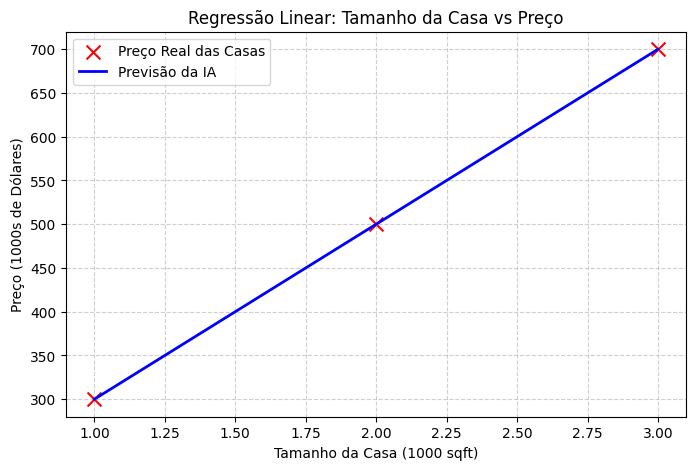

In [43]:
w_treinado, b_treinado = gradiente_decendente(x, y, w, b, alpha, epocas)
tamanho_nova_casa = 1.5
preco_previsto = w_treinado * tamanho_nova_casa + b_treinado
print(f"O preço previsto para a casa de tamanho {tamanho_nova_casa} é de R$ {preco_previsto:.2f}")


plt.figure(figsize=(8, 5))
w_treinado, b_treinado = gradiente_decendente(x, y, w, b, alpha, epocas)
previsoes_da_ia = calcular_previsao(x, w_treinado, b_treinado)
plt.scatter(x, y, marker='x', color='red', s=100, label='Preço Real das Casas')
plt.plot(x, previsoes_da_ia, color='blue', linewidth=2, label='Previsão da IA')
plt.title("Regressão Linear: Tamanho da Casa vs Preço")
plt.xlabel("Tamanho da Casa (1000 sqft)")
plt.ylabel("Preço (1000s de Dólares)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
